# Diagnóstico de calidad de datos — AI4I 2020

## Objetivo

Evaluar la calidad del dataset AI4I 2020 antes de realizar limpieza, transformación o entrenamiento.

En esta etapa se identificarán posibles problemas de calidad y se justificará cada decisión. No se eliminarán ni modificarán registros sin analizar previamente su impacto.

In [1]:
from pathlib import Path

import pandas as pd

# Identificar la raíz del proyecto de forma independiente
# del lugar desde donde se ejecute el notebook.
RUTA_PROYECTO = Path.cwd()

if RUTA_PROYECTO.name == "notebooks":
    RUTA_PROYECTO = RUTA_PROYECTO.parent

RUTA_DATOS = RUTA_PROYECTO / "data" / "raw" / "ai4i2020.csv"

print(f"Ruta del dataset: {RUTA_DATOS}")
print(f"¿El archivo existe?: {RUTA_DATOS.exists()}")

Ruta del dataset: c:\Users\PC\Documents\Incoex\PROYECTO INTEGRADOR DE ANÁLISIS DE DATOS\Proyecto Integrador\data\raw\ai4i2020.csv
¿El archivo existe?: True


## 1. Carga y estructura general

Se carga el archivo producido por la etapa de ingesta. En este punto los datos se conservan sin limpieza ni transformación para diagnosticar su estado original.

In [2]:
# Cargar los datos de la capa raw sin modificarlos.
df = pd.read_csv(RUTA_DATOS)

print(f"Cantidad de filas: {df.shape[0]:,}")
print(f"Cantidad de columnas: {df.shape[1]}")
print("\nNombres de las columnas:")

for columna in df.columns:
    print(f"- {columna}")

display(df.head())

Cantidad de filas: 10,000
Cantidad de columnas: 14

Nombres de las columnas:
- UID
- Product ID
- Type
- Air temperature
- Process temperature
- Rotational speed
- Torque
- Tool wear
- Machine failure
- TWF
- HDF
- PWF
- OSF
- RNF


,UID,Product ID,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### 1.1 Tipos de datos

Se revisan los tipos detectados por pandas para identificar columnas numéricas almacenadas como texto o variables categóricas interpretadas incorrectamente.

In [3]:
# Mostrar el tipo de dato, los valores no nulos y el uso de memoria.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   UID                  10000 non-null  int64  
 1   Product ID           10000 non-null  str    
 2   Type                 10000 non-null  str    
 3   Air temperature      10000 non-null  float64
 4   Process temperature  10000 non-null  float64
 5   Rotational speed     10000 non-null  int64  
 6   Torque               10000 non-null  float64
 7   Tool wear            10000 non-null  int64  
 8   Machine failure      10000 non-null  int64  
 9   TWF                  10000 non-null  int64  
 10  HDF                  10000 non-null  int64  
 11  PWF                  10000 non-null  int64  
 12  OSF                  10000 non-null  int64  
 13  RNF                  10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
memory usage: 1.1 MB


**Conclusión sobre los tipos de datos:**  
Las 14 columnas tienen tipos coherentes con su contenido. Las variables categóricas `Product ID` y `Type` fueron interpretadas como texto, mientras que las mediciones y los indicadores de falla son numéricos. Por lo tanto, no se requiere corregir tipos en esta etapa. Más adelante se verificará que las columnas binarias solamente contengan los valores 0 y 1.

## 2. Valores faltantes

Se cuantifican los valores nulos reconocidos por pandas. No se eliminarán registros sin analizar primero la cantidad y el impacto de los datos faltantes.

In [4]:
# Calcular la cantidad y el porcentaje de valores faltantes por columna.
faltantes = pd.DataFrame({
    "cantidad_faltante": df.isna().sum(),
    "porcentaje_faltante": (df.isna().mean() * 100).round(2)
})

display(faltantes)
print(f"Total de valores faltantes: {df.isna().sum().sum()}")

,cantidad_faltante,porcentaje_faltante
UID,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature,0,0.0
Process temperature,0,0.0
Rotational speed,0,0.0
Torque,0,0.0
Tool wear,0,0.0
Machine failure,0,0.0
TWF,0,0.0


Total de valores faltantes: 0


**Conclusión sobre valores faltantes:**  
No se encontraron valores nulos en ninguna columna: las 10.000 filas están completas. Por lo tanto, no es necesario eliminar filas ni aplicar técnicas de imputación. Sin embargo, también se revisarán posibles valores faltantes representados mediante símbolos o textos.

In [5]:
# Símbolos y textos que podrían representar datos faltantes.
marcadores_faltantes = {
    "", "?", "-", "--", "na", "n/a",
    "null", "none", "nan", "missing", "unknown"
}

resultados_simbolos = []

# Convertir temporalmente cada columna a texto únicamente para buscar marcadores.
for columna in df.columns:
    valores_normalizados = (
        df[columna]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    cantidad = valores_normalizados.isin(marcadores_faltantes).sum()

    if cantidad > 0:
        resultados_simbolos.append({
            "columna": columna,
            "cantidad": cantidad
        })

if resultados_simbolos:
    display(pd.DataFrame(resultados_simbolos))
else:
    print("No se encontraron valores faltantes codificados mediante símbolos.")

No se encontraron valores faltantes codificados mediante símbolos.


**Conclusión sobre valores faltantes codificados:**  
No se encontraron cadenas vacías, símbolos ni textos utilizados comúnmente para representar datos faltantes. Los valores cero no se consideran faltantes, ya que tienen un significado válido en los indicadores binarios de fallas.

## 3. Registros duplicados

Se buscan filas completamente repetidas y valores duplicados en los identificadores `UID` y `Product ID`. No se eliminarán registros automáticamente, porque primero debe determinarse si una repetición representa un error o una observación válida.

In [6]:
# Contar filas completamente idénticas.
filas_duplicadas = df.duplicated().sum()

# Revisar duplicados en los identificadores del dataset.
uid_duplicados = df["UID"].duplicated().sum()
producto_duplicados = df["Product ID"].duplicated().sum()

print(f"Filas completamente duplicadas: {filas_duplicadas}")
print(f"UID duplicados: {uid_duplicados}")
print(f"Product ID duplicados: {producto_duplicados}")

Filas completamente duplicadas: 0
UID duplicados: 0
Product ID duplicados: 0


## 4. Consistencia de categorías

Se revisan los valores únicos y la frecuencia de la columna `Type` para detectar diferencias de mayúsculas, espacios adicionales, errores de escritura o categorías inesperadas.

In [7]:
# Mostrar todas las categorías y su frecuencia.
distribucion_tipo = (
    df["Type"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("categoria")
    .reset_index(name="cantidad")
)

display(distribucion_tipo)

print(f"Número de categorías: {df['Type'].nunique(dropna=False)}")
print(f"Categorías encontradas: {sorted(df['Type'].unique().tolist())}")

,categoria,cantidad
0,H,1003
1,L,6000
2,M,2997


Número de categorías: 3
Categorías encontradas: ['H', 'L', 'M']


**Conclusión sobre categorías:**  
La columna `Type` contiene únicamente las tres categorías esperadas: `H`, `L` y `M`. No se encontraron diferencias de mayúsculas, espacios adicionales ni categorías desconocidas. La categoría `L` es la más frecuente, pero esto corresponde a la distribución original del dataset y no constituye un error de calidad.

## 5. Consistencia lógica de los registros

Se verifican relaciones internas entre columnas para detectar registros que, aunque tengan tipos válidos, contradigan las reglas conocidas del dataset.

In [8]:
# Verificar que UID siga la secuencia esperada.
uid_esperado = pd.Series(range(1, len(df) + 1), index=df.index)
uid_inconsistentes = (df["UID"] != uid_esperado).sum()

# La primera letra de Product ID debe coincidir con Type.
tipo_producto_inconsistente = (
    df["Product ID"].str[0] != df["Type"]
).sum()

# Machine failure debe indicar si ocurrió al menos un tipo de falla.
columnas_falla = ["TWF", "HDF", "PWF", "OSF", "RNF"]
falla_calculada = df[columnas_falla].max(axis=1)

fallas_inconsistentes = (
    df["Machine failure"] != falla_calculada
).sum()

print(f"UID fuera de secuencia: {uid_inconsistentes}")
print(
    "Product ID que no coincide con Type: "
    f"{tipo_producto_inconsistente}"
)
print(
    "Machine failure inconsistente con los tipos de falla: "
    f"{fallas_inconsistentes}"
)

UID fuera de secuencia: 0
Product ID que no coincide con Type: 0
Machine failure inconsistente con los tipos de falla: 27


### 5.1 Análisis de la relación entre la falla general y los tipos de falla

Se estudian por separado los casos donde existe una falla general sin un tipo específico registrado y los casos donde aparece un tipo de falla, pero la variable general indica que la máquina no falló.

In [9]:
# Identificar los dos tipos posibles de inconsistencia.
falla_sin_tipo = (
    (df["Machine failure"] == 1) &
    (falla_calculada == 0)
)

tipo_sin_falla_general = (
    (df["Machine failure"] == 0) &
    (falla_calculada == 1)
)

print(
    "Machine failure = 1, pero ningún tipo de falla = 1: "
    f"{falla_sin_tipo.sum()}"
)

print(
    "Machine failure = 0, pero algún tipo de falla = 1: "
    f"{tipo_sin_falla_general.sum()}"
)

print("\nTipos de falla presentes en el segundo caso:")
display(
    df.loc[tipo_sin_falla_general, columnas_falla]
    .sum()
    .to_frame(name="cantidad")
)

Machine failure = 1, pero ningún tipo de falla = 1: 9
Machine failure = 0, pero algún tipo de falla = 1: 18

Tipos de falla presentes en el segundo caso:


,cantidad
TWF,0
HDF,0
PWF,0
OSF,0
RNF,18


**Conclusión sobre consistencia lógica:**  
Los identificadores `UID` siguen la secuencia esperada y la letra inicial de cada `Product ID` coincide con su categoría `Type`.

Sin embargo, se encontraron 27 registros (0,27 % del dataset) con inconsistencias entre `Machine failure` y los tipos específicos de falla:

- 9 registros tienen `Machine failure = 1`, pero ninguno de los cinco tipos de falla está activo.
- 18 registros tienen `Machine failure = 0`, pero presentan `RNF = 1`.

Según la documentación de UCI, `Machine failure` debería tomar el valor 1 cuando al menos uno de los modos de falla está activo.

**Decisión:** los registros se conservarán sin modificación porque no es posible determinar con certeza cuál etiqueta debe corregirse. La capa raw debe permanecer intacta y el hallazgo se documentará como posible ruido de etiquetado. Además, `TWF`, `HDF`, `PWF`, `OSF` y `RNF` no se utilizarán como variables predictoras porque describen directamente el resultado de falla y producirían fuga de información (*target leakage*).



In [10]:
# Verificar que el objetivo y los tipos de falla solo contengan 0 y 1.
columnas_binarias = [
    "Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"
]

for columna in columnas_binarias:
    valores = sorted(df[columna].unique().tolist())
    print(f"{columna}: {valores}")

Machine failure: [0, 1]
TWF: [0, 1]
HDF: [0, 1]
PWF: [0, 1]
OSF: [0, 1]
RNF: [0, 1]


**Conclusión sobre variables binarias:**  
Las columnas `Machine failure`, `TWF`, `HDF`, `PWF`, `OSF` y `RNF` contienen únicamente los valores 0 y 1. No se encontraron  otros valores.

## 6. Rangos físicos y unidades

Se revisan los rangos de las variables operacionales para detectar valores físicamente imposibles y posibles errores de unidad. Los valores extremos todavía no se eliminarán, porque un valor poco frecuente puede representar una anomalía real de la maquinaria.

In [11]:
# Unidades indicadas en la documentación oficial del dataset.
unidades = {
    "Air temperature": "K",
    "Process temperature": "K",
    "Rotational speed": "rpm",
    "Torque": "Nm",
    "Tool wear": "min"
}

columnas_operacion = list(unidades.keys())

# Resumir los rangos observados.
resumen_rangos = (
    df[columnas_operacion]
    .agg(["min", "max", "mean", "median"])
    .T
    .round(2)
)

resumen_rangos.insert(
    0,
    "unidad",
    [unidades[columna] for columna in resumen_rangos.index]
)

display(resumen_rangos)

# Comprobar condiciones físicamente imposibles o incompatibles.
reglas_imposibles = {
    "Temperatura del aire menor o igual a 0 K":
        (df["Air temperature"] <= 0).sum(),

    "Temperatura del proceso menor o igual a 0 K":
        (df["Process temperature"] <= 0).sum(),

    "Temperatura del proceso menor o igual a la del aire":
        (df["Process temperature"] <= df["Air temperature"]).sum(),

    "Velocidad de rotación menor o igual a 0 rpm":
        (df["Rotational speed"] <= 0).sum(),

    "Torque negativo":
        (df["Torque"] < 0).sum(),

    "Desgaste de herramienta negativo":
        (df["Tool wear"] < 0).sum()
}

display(
    pd.DataFrame.from_dict(
        reglas_imposibles,
        orient="index",
        columns=["cantidad"]
    )
)

,unidad,min,max,mean,median
Air temperature,K,295.3,304.5,300.00,300.1
Process temperature,K,305.7,313.8,310.01,310.1
Rotational speed,rpm,1168.0,2886.0,1538.78,1503.0
Torque,Nm,3.8,76.6,39.99,40.1
Tool wear,min,0.0,253.0,107.95,108.0


,cantidad
Temperatura del aire menor o igual a 0 K,0
Temperatura del proceso menor o igual a 0 K,0
Temperatura del proceso menor o igual a la del aire,0
Velocidad de rotación menor o igual a 0 rpm,0
Torque negativo,0
Desgaste de herramienta negativo,0


**Conclusión sobre rangos y unidades:**  
Las temperaturas se encuentran alrededor de 300 K y 310 K, lo cual es coherente con la unidad Kelvin indicada por UCI. La velocidad de rotación es positiva y se expresa en rpm; el torque no presenta valores negativos y el desgaste de herramienta se encuentra entre 0 y 253 minutos.

Además, la temperatura del proceso siempre es mayor que la temperatura del aire, como corresponde al proceso con el que se generó el dataset. No se encontraron datos físicamente imposibles ni evidencias de errores de unidad.

Los valores mínimos y máximos no se consideran errores automáticamente. Posteriormente se analizarán como posibles valores extremos o anomalías.

## 7. Cardinalidad

Se calcula la cantidad y el porcentaje de valores únicos de cada variable. Este análisis permite identificar columnas constantes, categorías de baja cardinalidad e identificadores con un valor diferente en cada registro.

In [12]:
# Calcular la cantidad y el porcentaje de valores únicos.
cardinalidad = pd.DataFrame({
    "valores_unicos": df.nunique(dropna=False),
    "porcentaje_unicos": (
        df.nunique(dropna=False) / len(df) * 100
    ).round(2)
})

# Identificar columnas que funcionan como identificadores únicos.
cardinalidad["es_identificador_unico"] = (
    cardinalidad["valores_unicos"] == len(df)
)

display(
    cardinalidad.sort_values(
        by="valores_unicos",
        ascending=False
    )
)

,valores_unicos,porcentaje_unicos,es_identificador_unico
UID,10000,100.00,True
Product ID,10000,100.00,True
Rotational speed,941,9.41,False
Torque,577,5.77,False
Tool wear,246,2.46,False
Air temperature,93,0.93,False
Process temperature,82,0.82,False
Type,3,0.03,False
Machine failure,2,0.02,False
TWF,2,0.02,False


**Conclusión sobre cardinalidad:**  
No existen columnas constantes. `UID` y `Product ID` presentan 10.000 valores únicos, uno por cada registro. Estas columnas se conservarán para trazabilidad, pero no se usarán como variables del modelo porque son identificadores y podrían provocar memorización sin aportar información operacional.

`Type` tiene tres categorías y podrá utilizarse después de aplicar una codificación categórica. Las variables operacionales presentan variabilidad suficiente para el análisis. `Machine failure` y los cinco tipos de falla tienen cardinalidad dos porque son variables binarias.

## 8. Asimetría de las variables numéricas

Se calcula la asimetría de las variables operacionales. Una asimetría elevada puede indicar una cola larga, valores extremos o la necesidad de aplicar transformaciones durante el modelado.

In [13]:
# Clasificar la intensidad de la asimetría.
def clasificar_asimetria(valor):
    valor_absoluto = abs(valor)

    if valor_absoluto < 0.5:
        return "Baja"
    elif valor_absoluto < 1:
        return "Moderada"
    else:
        return "Alta"


asimetria = (
    df[columnas_operacion]
    .skew()
    .to_frame(name="skewness")
)

asimetria["valor_absoluto"] = asimetria["skewness"].abs()
asimetria["nivel"] = asimetria["skewness"].apply(
    clasificar_asimetria
)

display(
    asimetria.sort_values(
        by="valor_absoluto",
        ascending=False
    ).round(3)
)

,skewness,valor_absoluto,nivel
Rotational speed,1.993,1.993,Alta
Air temperature,0.114,0.114,Baja
Tool wear,0.027,0.027,Baja
Process temperature,0.015,0.015,Baja
Torque,-0.010,0.010,Baja


**Conclusión sobre asimetría:**  
Las temperaturas, el torque y el desgaste de herramienta presentan una distribución aproximadamente simétrica, con valores absolutos de *skewness* inferiores a 0,5.

`Rotational speed` presenta una asimetría positiva alta de 1,993, lo que indica la existencia de una cola hacia velocidades elevadas. Estos valores no se eliminarán automáticamente porque podrían representar comportamientos anómalos relevantes para el objetivo del proyecto.

### 8.1 Visualización de la asimetría

Se utilizan histogramas individuales porque las variables tienen escalas y unidades diferentes. Las líneas verticales representan la media y la mediana; una cola larga y una separación entre ambas pueden evidenciar asimetría.

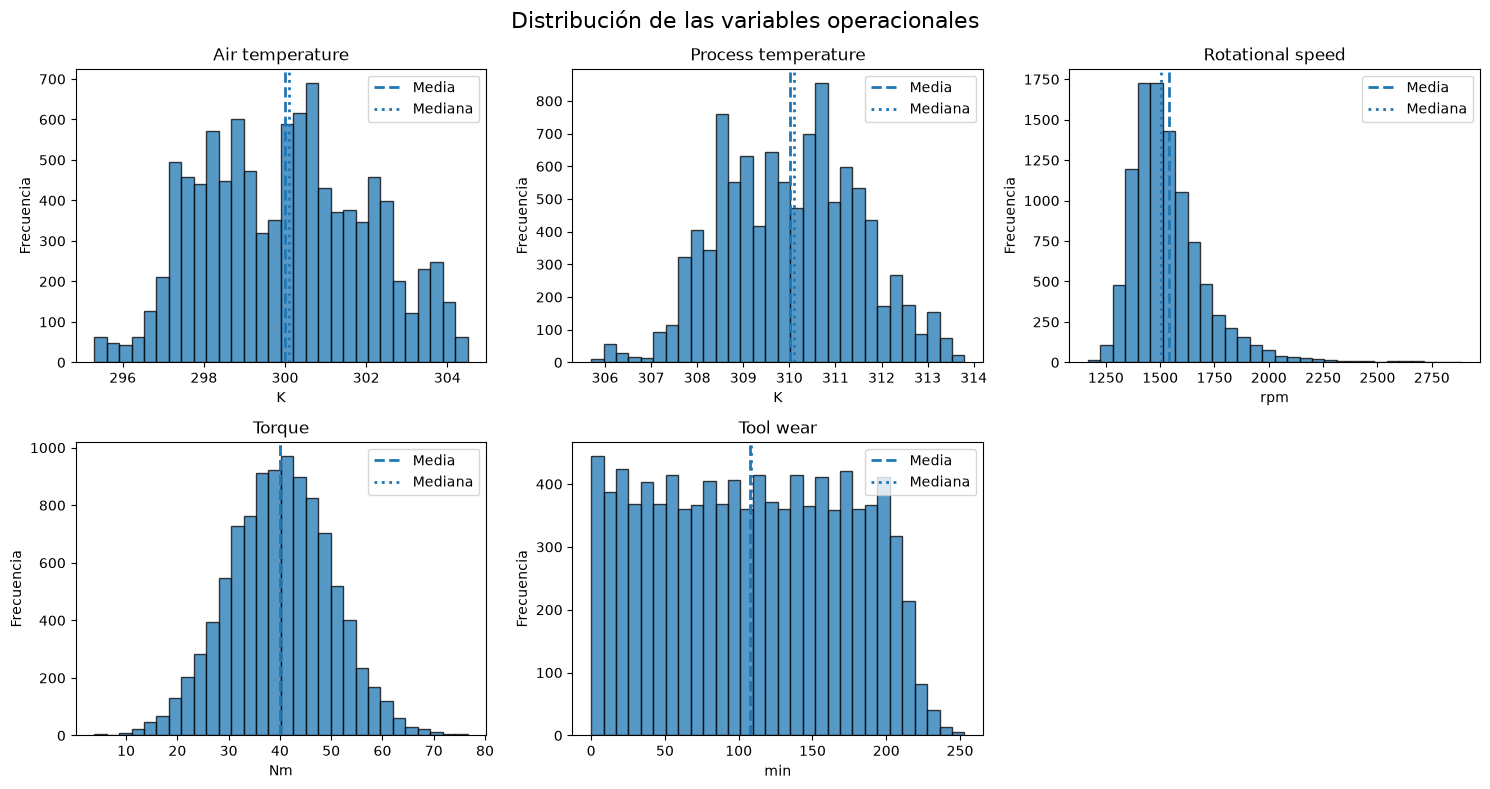

In [14]:
import matplotlib.pyplot as plt

# Crear un histograma independiente para cada variable operacional.
fig, ejes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 8)
)

ejes = ejes.flatten()

for eje, columna in zip(ejes, columnas_operacion):
    eje.hist(
        df[columna],
        bins=30,
        alpha=0.75,
        edgecolor="black"
    )

    eje.axvline(
        df[columna].mean(),
        linestyle="--",
        linewidth=2,
        label="Media"
    )

    eje.axvline(
        df[columna].median(),
        linestyle=":",
        linewidth=2,
        label="Mediana"
    )

    eje.set_title(columna)
    eje.set_xlabel(unidades[columna])
    eje.set_ylabel("Frecuencia")
    eje.legend()

# Eliminar el sexto espacio porque solamente tenemos cinco variables.
fig.delaxes(ejes[-1])

fig.suptitle(
    "Distribución de las variables operacionales",
    fontsize=16
)

plt.tight_layout()
plt.show()

**Interpretación del gráfico:**  
La visualización confirma que `Rotational speed` presenta la mayor asimetría, con una cola pronunciada hacia velocidades elevadas y la media ligeramente por encima de la mediana. Las demás variables no muestran una asimetría importante.

Los valores de la cola no serán eliminados, ya que podrían contener comportamientos anómalos relevantes para detectar fallas.

## 9. Valores extremos y anomalías estadísticas

Se utiliza el rango intercuartílico (IQR) para identificar valores estadísticamente extremos. Estos registros se analizarán, pero no se eliminarán automáticamente porque el objetivo del proyecto es detectar comportamientos anómalos asociados con fallas.

In [15]:
resultados_extremos = []

for columna in columnas_operacion:
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara_extremos = (
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    )

    cantidad = mascara_extremos.sum()

    resultados_extremos.append({
        "variable": columna,
        "limite_inferior": round(limite_inferior, 2),
        "limite_superior": round(limite_superior, 2),
        "cantidad_extremos": cantidad,
        "porcentaje_extremos": round(cantidad / len(df) * 100, 2)
    })

tabla_extremos = pd.DataFrame(resultados_extremos)
display(tabla_extremos)

,variable,limite_inferior,limite_superior,cantidad_extremos,porcentaje_extremos
0,Air temperature,293.50,306.30,0,0.00
1,Process temperature,305.35,314.55,0,0.00
2,Rotational speed,1139.50,1895.50,418,4.18
3,Torque,12.80,67.20,69,0.69
4,Tool wear,-110.50,325.50,0,0.00


**Conclusión sobre valores extremos:**  
El método IQR identificó 418 valores extremos en `Rotational speed` y 69 en `Torque`. No se detectaron valores extremos en las temperaturas ni en el desgaste de herramienta.

Estos registros no se consideran automáticamente errores, porque están dentro de rangos físicamente posibles. Tampoco se eliminarán, ya que las velocidades y torques inusuales pueden ser precisamente las señales necesarias para detectar anomalías y fallas de maquinaria.

### 9.1 Relación entre valores extremos y fallas

Se compara la frecuencia de `Machine failure` dentro y fuera de los valores extremos. Este análisis ayuda a determinar si eliminarlos destruiría información útil para la detección de anomalías.

In [16]:
mascaras_extremos = {}

# Reconstruir una máscara de valores extremos para cada variable.
for columna in columnas_operacion:
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascaras_extremos[columna] = (
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    )

# Identificar registros extremos en al menos una variable.
es_extremo = pd.DataFrame(mascaras_extremos).any(axis=1)

comparacion_extremos = (
    df.assign(
        grupo=es_extremo.map({
            True: "Con algún valor extremo",
            False: "Sin valores extremos"
        })
    )
    .groupby("grupo")["Machine failure"]
    .agg(
        registros="size",
        fallas="sum",
        tasa_falla="mean"
    )
)

comparacion_extremos["tasa_falla_porcentaje"] = (
    comparacion_extremos["tasa_falla"] * 100
).round(2)

display(
    comparacion_extremos[
        ["registros", "fallas", "tasa_falla_porcentaje"]
    ]
)

,registros,fallas,tasa_falla_porcentaje
grupo,,,
Con algún valor extremo,459,72,15.69
Sin valores extremos,9541,267,2.80


**Relación de los extremos con las fallas:**  
Los 459 registros que presentan al menos un valor extremo tienen una tasa de falla del 15,69 %, mientras que los registros sin valores extremos tienen una tasa de apenas 2,80 %.

La tasa de falla es aproximadamente 5,6 veces mayor en los registros extremos. Esto no demuestra por sí solo una relación causal, pero confirma que contienen información relevante para detectar comportamientos anómalos. Por esta razón, se conservarán.

## 10. Desbalance de la variable objetivo

Se analiza la distribución de `Machine failure`. En mantenimiento predictivo es esperable que las fallas sean menos frecuentes que el funcionamiento normal, pero este desbalance debe considerarse al evaluar el modelo.

,clase,descripcion,cantidad,porcentaje
0,0,Funcionamiento normal,9661,96.61
1,1,Falla,339,3.39


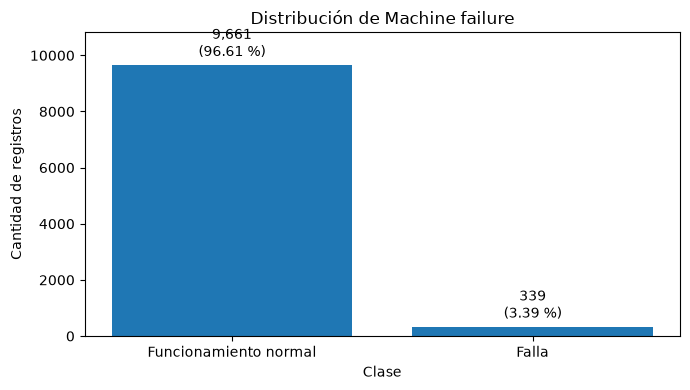

In [17]:
# Calcular cantidad y porcentaje de cada clase.
distribucion_objetivo = (
    df["Machine failure"]
    .value_counts()
    .sort_index()
    .rename_axis("clase")
    .reset_index(name="cantidad")
)

distribucion_objetivo["porcentaje"] = (
    distribucion_objetivo["cantidad"] / len(df) * 100
).round(2)

distribucion_objetivo["descripcion"] = (
    distribucion_objetivo["clase"]
    .map({
        0: "Funcionamiento normal",
        1: "Falla"
    })
)

display(
    distribucion_objetivo[
        ["clase", "descripcion", "cantidad", "porcentaje"]
    ]
)

# Graficar la distribución de las clases.
fig, eje = plt.subplots(figsize=(7, 4))

barras = eje.bar(
    distribucion_objetivo["descripcion"],
    distribucion_objetivo["cantidad"]
)

etiquetas = [
    f"{cantidad:,}\n({porcentaje:.2f} %)"
    for cantidad, porcentaje in zip(
        distribucion_objetivo["cantidad"],
        distribucion_objetivo["porcentaje"]
    )
]

eje.bar_label(barras, labels=etiquetas, padding=3)
eje.set_title("Distribución de Machine failure")
eje.set_xlabel("Clase")
eje.set_ylabel("Cantidad de registros")
eje.set_ylim(
    0,
    distribucion_objetivo["cantidad"].max() * 1.12
)

plt.tight_layout()
plt.show()

**Conclusión sobre desbalance:**  
La variable objetivo está fuertemente desbalanceada: el 96,61 % de los registros representa funcionamiento normal y solamente el 3,39 % corresponde a fallas.

Este comportamiento es esperable en mantenimiento predictivo, porque las fallas son eventos poco frecuentes. No se eliminarán registros normales en esta etapa. Para evaluar el modelo no será suficiente utilizar exactitud (*accuracy*); deberán considerarse métricas como *recall*, precisión, F1, PR-AUC y la matriz de confusión.

## 11. Correlación entre variables operacionales

Se calcula la correlación lineal entre las variables operacionales. Una correlación absoluta igual o superior a 0,80 se señalará como elevada, pero las variables no se eliminarán sin analizar primero su significado físico.

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
Air temperature,1.000,0.876,0.023,-0.014,0.014
Process temperature,0.876,1.000,0.019,-0.014,0.013
Rotational speed,0.023,0.019,1.000,-0.875,0.000
Torque,-0.014,-0.014,-0.875,1.000,-0.003
Tool wear,0.014,0.013,0.000,-0.003,1.000


Pares con correlación absoluta igual o superior a 0.80:


,variable_1,variable_2,correlacion
0,Air temperature,Process temperature,0.876
1,Rotational speed,Torque,-0.875


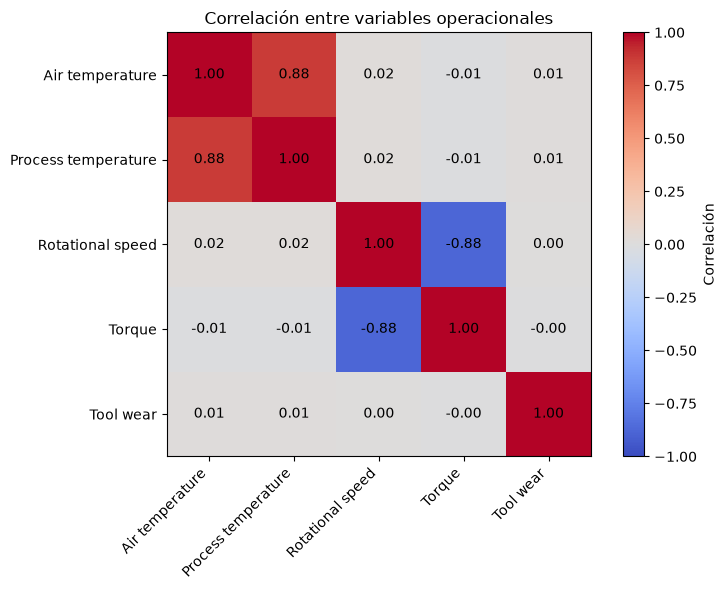

In [18]:
# Calcular la matriz de correlación.
correlacion = df[columnas_operacion].corr()

display(correlacion.round(3))

# Identificar pares con correlación absoluta igual o superior a 0.80.
pares_correlacion_alta = []

for posicion_1 in range(len(columnas_operacion)):
    for posicion_2 in range(posicion_1 + 1, len(columnas_operacion)):
        variable_1 = columnas_operacion[posicion_1]
        variable_2 = columnas_operacion[posicion_2]
        valor = correlacion.loc[variable_1, variable_2]

        if abs(valor) >= 0.80:
            pares_correlacion_alta.append({
                "variable_1": variable_1,
                "variable_2": variable_2,
                "correlacion": round(valor, 3)
            })

print("Pares con correlación absoluta igual o superior a 0.80:")
display(pd.DataFrame(pares_correlacion_alta))

# Graficar la matriz de correlación.
fig, eje = plt.subplots(figsize=(8, 6))

imagen = eje.imshow(
    correlacion,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

eje.set_xticks(range(len(columnas_operacion)))
eje.set_yticks(range(len(columnas_operacion)))
eje.set_xticklabels(columnas_operacion, rotation=45, ha="right")
eje.set_yticklabels(columnas_operacion)

for fila in range(len(columnas_operacion)):
    for columna in range(len(columnas_operacion)):
        eje.text(
            columna,
            fila,
            f"{correlacion.iloc[fila, columna]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(imagen, ax=eje, label="Correlación")
eje.set_title("Correlación entre variables operacionales")

plt.tight_layout()
plt.show()

**Conclusión sobre correlación:**  
Se encontraron dos relaciones lineales elevadas. La temperatura del aire y la temperatura del proceso tienen una correlación positiva de 0,876. La velocidad de rotación y el torque tienen una correlación negativa de -0,875.

Estas relaciones son coherentes con la forma en que se generó el dataset y con el comportamiento físico de la maquinaria. Por lo tanto, ninguna variable se eliminará automáticamente. Se podrá evaluar después la diferencia de temperaturas y la potencia calculada a partir de velocidad y torque.

## 12. Riesgo de fuga de información

Se determina el papel de cada columna para evitar utilizar como entrada del modelo variables que revelen directamente si ocurrió una falla.

In [19]:
# Documentar el papel que tendrá cada columna en el proyecto.
roles_columnas = pd.DataFrame([
    ["UID", "Identificador", "No", "Solo trazabilidad"],
    ["Product ID", "Identificador", "No", "Es único y contiene información redundante de Type"],
    ["Type", "Característica", "Sí", "Requiere codificación categórica"],
    ["Air temperature", "Característica", "Sí", "Medición operacional"],
    ["Process temperature", "Característica", "Sí", "Medición operacional"],
    ["Rotational speed", "Característica", "Sí", "Medición operacional"],
    ["Torque", "Característica", "Sí", "Medición operacional"],
    ["Tool wear", "Característica", "Sí", "Medición operacional"],
    ["Machine failure", "Etiqueta de evaluación", "No", "Indica si ocurrió una falla"],
    ["TWF", "Tipo de falla", "No", "Revela directamente una causa de falla"],
    ["HDF", "Tipo de falla", "No", "Revela directamente una causa de falla"],
    ["PWF", "Tipo de falla", "No", "Revela directamente una causa de falla"],
    ["OSF", "Tipo de falla", "No", "Revela directamente una causa de falla"],
    ["RNF", "Tipo de falla", "No", "Revela directamente una causa de falla"]
], columns=[
    "columna",
    "rol",
    "usar_como_entrada",
    "justificacion"
])

display(roles_columnas)

,columna,rol,usar_como_entrada,justificacion
0,UID,Identificador,No,Solo trazabilidad
1,Product ID,Identificador,No,Es único y contiene información redundante de ...
2,Type,Característica,Sí,Requiere codificación categórica
3,Air temperature,Característica,Sí,Medición operacional
4,Process temperature,Característica,Sí,Medición operacional
5,Rotational speed,Característica,Sí,Medición operacional
6,Torque,Característica,Sí,Medición operacional
7,Tool wear,Característica,Sí,Medición operacional
8,Machine failure,Etiqueta de evaluación,No,Indica si ocurrió una falla
9,TWF,Tipo de falla,No,Revela directamente una causa de falla


**Conclusión sobre fuga de información:**  
Para entrenar el detector de anomalías se utilizarán únicamente `Type` y las cinco variables operacionales.

`UID` y `Product ID` se excluirán porque son identificadores. `Machine failure` se reservará como etiqueta para evaluar el desempeño del detector, pero no se utilizará durante su entrenamiento.

Las columnas `TWF`, `HDF`, `PWF`, `OSF` y `RNF` también se excluirán de las entradas porque describen directamente tipos de falla. Utilizarlas permitiría al modelo conocer anticipadamente parte del resultado y produciría fuga de información.

## 13. Fechas y continuidad temporal

Se verifica si existen columnas de fecha o tiempo que permitan analizar fechas inválidas, frecuencia de muestreo o gaps temporales.

In [20]:
# Buscar nombres de columnas que indiquen una fecha o marca temporal.
terminos_temporales = ["date", "time", "timestamp"]

posibles_columnas_temporales = [
    columna
    for columna in df.columns
    if any(
        termino in columna.lower()
        for termino in terminos_temporales
    )
]

# Revisar únicamente la continuidad del identificador secuencial.
saltos_uid = (
    df["UID"]
    .sort_values()
    .diff()
    .dropna()
    .ne(1)
    .sum()
)

print(
    "Posibles columnas temporales: "
    f"{posibles_columnas_temporales}"
)
print(f"Saltos encontrados en la secuencia UID: {saltos_uid}")

Posibles columnas temporales: []
Saltos encontrados en la secuencia UID: 0


**Conclusión sobre temporalidad:**  
El dataset no contiene columnas de fecha, hora ni marcas temporales. Por lo tanto, no es posible evaluar fechas inválidas, frecuencia de muestreo o gaps temporales reales.

La secuencia de `UID` está completa y ordenada, pero solamente funciona como identificador; no se interpretará como una unidad de tiempo.

## 14. Resumen de decisiones de calidad

| Aspecto evaluado | Resultado | Decisión justificada |
|---|---|---|
| Valores faltantes | No se encontraron valores nulos | No se requiere imputación ni eliminación |
| Faltantes codificados | No se encontraron símbolos o textos usados como faltantes | No se requiere reemplazo |
| Duplicados | No existen filas ni identificadores duplicados | No se eliminan registros |
| Tipos incorrectos | Los tipos son coherentes con el contenido | No se convierten tipos |
| Categorías inconsistentes | `Type` contiene únicamente H, L y M | No se corrigen categorías |
| Registros inconsistentes | Se encontraron 27 contradicciones entre `Machine failure` y los tipos de falla | Se conservan y documentan como posible ruido de etiquetado |
| Variables binarias | Todas contienen únicamente 0 y 1 | No se requiere corrección |
| Datos imposibles | No se encontraron valores físicamente imposibles | No se eliminan registros |
| Errores de unidad | Los rangos son coherentes con K, rpm, Nm y min | Se mantienen las unidades originales |
| Cardinalidad | `UID` y `Product ID` son únicos | Se conservan para trazabilidad, pero se excluyen del modelo |
| Asimetría | `Rotational speed` presenta asimetría positiva alta | No se elimina; se evaluará su tratamiento en el pipeline de características |
| Valores extremos | 459 registros tienen al menos un extremo | Se conservan porque su tasa de falla es 15,69 %, frente a 2,80 % en los demás |
| Desbalance | Solo 3,39 % de los registros corresponde a fallas | Se usarán métricas adecuadas para clases minoritarias |
| Correlación elevada | Temperaturas: 0,876; velocidad y torque: -0,875 | Se conservan por su significado físico |
| Leakage | Los tipos de falla revelan directamente el resultado | Se excluyen de las entradas del modelo |
| Fechas inválidas | No aplica porque no existen fechas | Queda documentado |
| Gaps temporales | No pueden evaluarse sin timestamps | `UID` no se utilizará como tiempo |
| Anomalías estadísticas | Se detectaron extremos principalmente en velocidad y torque | Se conservan porque son relevantes para el problema |

## Conclusión general

El dataset presenta una calidad estructural alta: no contiene valores faltantes, duplicados, tipos incorrectos ni valores físicamente imposibles.

Los principales riesgos identificados son el fuerte desbalance de la variable objetivo, las 27 inconsistencias entre la falla general y los tipos de falla, la presencia de valores extremos asociados con una mayor tasa de falla y el riesgo de fuga de información producido por las columnas que describen tipos de falla.

La capa raw permanecerá sin modificaciones. Las exclusiones y transformaciones necesarias se implementarán posteriormente mediante un pipeline reproducible, conservando los identificadores para trazabilidad y las etiquetas únicamente para evaluación.